In [135]:
import utils

from importlib import reload

reload(utils)


from utils import *

print('Loaded utility functions')

Loaded utility functions


In [136]:
T,V,S,VL,X = load_ARED_data()

ARED data loaded in.


In [100]:
train_begin = 600
train_end = 550*30 #until the end
 
V_train = V[train_begin:train_end,:]
S_train = S[train_begin:train_end,:]
VL_train = VL[train_begin:train_end,:]
T_train = T[train_begin:train_end,:]
X_train = X[train_begin:train_end,:]

print('Selected training data.')

Selected training data.


In [101]:
V_resampled,S_resampled,T_resampled,X_resampled,VL_resampled,timeseries_dict = get_ARED_data_resampled_for_detection(T_train,V_train,S_train,VL_train,X_train)


# NOTE: Theres an error with timeseries_dict not including acceleration

# train with all data present (including CAT Vehicle)

In [68]:
from detector_dev.Process_RingRoad_Simulat  ion.get_rec_errors_normalized_single_lane import *

Libraries loaded.


In [83]:
dv_dt_vals = np.gradient(V_train,.1,axis=0)
dv_dt_vals.shape

(15900, 21)

In [107]:
max_V = np.max(V_resampled)
max_S = np.max(S_resampled)

DS_DT = VL_resampled - V_resampled
max_DS_DT = np.max(np.abs(DS_DT))

max_DV_DT = np.max(np.abs(dv_dt_vals))

In [108]:
normalizing_factors=[max_V, max_DS_DT, max_S, max_DV_DT]

print(normalizing_factors)

[10.868883839165601, 13.443900710894539, 30.88161783994193, 1.4782409816592157]


In [87]:
from detector_dev.Process_RingRoad_Simulation.get_rec_errors_normalized_single_lane import *

In [98]:
from copy import deepcopy

trajectory_dict = deepcopy(timeseries_dict)

warmup_period = 0.0

normalized_timeseries_list_with_AV,normalizing_factors_with_AV = make_timeseries_list_normalized(trajectory_dict)

In [ ]:
model_with_AV = get_cnn_lstm_ae_model(n_features=4)

In [91]:
from Detectors.Deep_Learning.AutoEncoders.utils import train_model,make_train_X

for i in range(4):
    train_X = make_train_X(normalized_timeseries_list_with_AV)
    print('Training data prepared.')
    model_file_name = 'normalized_ARED_detector_ALL_DATA'
    model = train_model(model_with_AV,train_X,model_file_name)

Training data prepared.
Creating new model.
Best loss 19.763433801560176
Beginning training.
Number epochs: 0 epoch step time: 0.8926427364349365
Epoch 0, total loss 818.455857, total predictions 210, avg loss 3.897409 2023-08-22 11:40:52.647984
Saving model. Best loss: 3.897408844175793
Number epochs: 1 epoch step time: 0.7968771457672119
Saving model. Best loss: 3.24953111239842
Number epochs: 2 epoch step time: 0.7804510593414307
Saving model. Best loss: 3.026973622185843
Number epochs: 3 epoch step time: 0.7441830635070801
Saving model. Best loss: 2.8852158807572863
Number epochs: 4 epoch step time: 0.7385599613189697
Saving model. Best loss: 2.8819243249439057
Number epochs: 5 epoch step time: 0.7526330947875977
Epoch 5, total loss 609.750361, total predictions 210, avg loss 2.903573 2023-08-22 11:40:56.460670
Number epochs: 6 epoch step time: 0.8417658805847168
Saving model. Best loss: 2.743161741892497
Number epochs: 7 epoch step time: 0.8174769878387451
Number epochs: 8 epoch s

Number epochs: 88 epoch step time: 0.7651181221008301
Number epochs: 89 epoch step time: 0.743894100189209
Number epochs: 90 epoch step time: 0.753140926361084
Epoch 90, total loss 354.242421, total predictions 210, avg loss 1.686869 2023-08-22 11:42:09.661715
Number epochs: 91 epoch step time: 0.7473170757293701
Number epochs: 92 epoch step time: 0.7319962978363037
Number epochs: 93 epoch step time: 0.75042724609375
Number epochs: 94 epoch step time: 0.7611739635467529
Number epochs: 95 epoch step time: 0.7349588871002197
Epoch 95, total loss 364.266858, total predictions 210, avg loss 1.734604 2023-08-22 11:42:13.388400
Number epochs: 96 epoch step time: 0.7364721298217773
Number epochs: 97 epoch step time: 0.757573127746582
Saving model. Best loss: 1.6522730600266229
Number epochs: 98 epoch step time: 0.7784111499786377
Number epochs: 99 epoch step time: 0.7420730590820312
Saving model. Best loss: 1.6426345802488782
Number epochs: 100 epoch step time: 0.743973970413208
Epoch 100, to

Number epochs: 37 epoch step time: 0.7561368942260742
Number epochs: 38 epoch step time: 0.7623538970947266
Saving model. Best loss: 1.5854955718630837
Number epochs: 39 epoch step time: 0.7523758411407471
Saving model. Best loss: 1.5716425816218058
Number epochs: 40 epoch step time: 0.7409467697143555
Epoch 40, total loss 332.432070, total predictions 210, avg loss 1.583010 2023-08-22 11:43:26.103724
Number epochs: 41 epoch step time: 0.73486328125
Number epochs: 42 epoch step time: 0.733461856842041
Number epochs: 43 epoch step time: 0.7402820587158203
Number epochs: 44 epoch step time: 0.7291579246520996
Number epochs: 45 epoch step time: 0.733989953994751
Epoch 45, total loss 330.127230, total predictions 210, avg loss 1.572034 2023-08-22 11:43:29.776156
Number epochs: 46 epoch step time: 0.751356840133667
Saving model. Best loss: 1.559209476198469
Number epochs: 47 epoch step time: 0.739799976348877
Number epochs: 48 epoch step time: 0.7424559593200684
Number epochs: 49 epoch step

Number epochs: 138 epoch step time: 0.7358951568603516
Number epochs: 139 epoch step time: 0.7409842014312744
Number epochs: 140 epoch step time: 0.7375049591064453
Epoch 140, total loss 304.056382, total predictions 210, avg loss 1.447888 2023-08-22 11:44:40.605592
Number epochs: 141 epoch step time: 0.7379050254821777
Number epochs: 142 epoch step time: 0.7328901290893555
Number epochs: 143 epoch step time: 0.7431538105010986
Number epochs: 144 epoch step time: 0.7260570526123047
Saving model. Best loss: 1.3868796189626058
Number epochs: 145 epoch step time: 0.7513372898101807
Epoch 145, total loss 294.317242, total predictions 210, avg loss 1.401511 2023-08-22 11:44:44.297574
Number epochs: 146 epoch step time: 1.211359977722168
Saving model. Best loss: 1.366978356951759
Number epochs: 147 epoch step time: 0.7555749416351318
Number epochs: 148 epoch step time: 0.7401180267333984
Number epochs: 149 epoch step time: 0.7337210178375244
Saving model. Best loss: 1.3547017460777646
Finish

Number epochs: 85 epoch step time: 0.7361600399017334
Epoch 85, total loss 278.409359, total predictions 210, avg loss 1.325759 2023-08-22 11:45:55.134944
Number epochs: 86 epoch step time: 0.7461838722229004
Number epochs: 87 epoch step time: 0.7561898231506348
Number epochs: 88 epoch step time: 0.7431399822235107
Number epochs: 89 epoch step time: 0.7376370429992676
Number epochs: 90 epoch step time: 0.7351069450378418
Epoch 90, total loss 283.284256, total predictions 210, avg loss 1.348973 2023-08-22 11:45:58.853861
Number epochs: 91 epoch step time: 0.7515649795532227
Number epochs: 92 epoch step time: 0.7387540340423584
Number epochs: 93 epoch step time: 0.7426478862762451
Number epochs: 94 epoch step time: 0.766901969909668
Number epochs: 95 epoch step time: 0.7419259548187256
Epoch 95, total loss 279.441246, total predictions 210, avg loss 1.330673 2023-08-22 11:46:02.596350
Number epochs: 96 epoch step time: 0.7443139553070068
Number epochs: 97 epoch step time: 0.7498958110809

Number epochs: 33 epoch step time: 0.7342112064361572
Number epochs: 34 epoch step time: 0.7365069389343262
Saving model. Best loss: 1.2092348791304088
Number epochs: 35 epoch step time: 0.739691972732544
Epoch 35, total loss 268.176646, total predictions 210, avg loss 1.277032 2023-08-22 11:47:11.021017
Number epochs: 36 epoch step time: 0.7381970882415771
Number epochs: 37 epoch step time: 0.7306728363037109
Number epochs: 38 epoch step time: 0.7330269813537598
Number epochs: 39 epoch step time: 0.7310748100280762
Number epochs: 40 epoch step time: 0.7299091815948486
Epoch 40, total loss 262.300318, total predictions 210, avg loss 1.249049 2023-08-22 11:47:14.684589
Number epochs: 41 epoch step time: 0.7341489791870117
Number epochs: 42 epoch step time: 0.7350659370422363
Number epochs: 43 epoch step time: 0.7415611743927002
Number epochs: 44 epoch step time: 0.7394990921020508
Number epochs: 45 epoch step time: 0.7476611137390137
Epoch 45, total loss 289.946711, total predictions 21

Number epochs: 139 epoch step time: 0.7504739761352539
Number epochs: 140 epoch step time: 0.7310981750488281
Epoch 140, total loss 262.283716, total predictions 210, avg loss 1.248970 2023-08-22 11:48:31.091813
Number epochs: 141 epoch step time: 0.7412800788879395
Number epochs: 142 epoch step time: 0.7389638423919678
Number epochs: 143 epoch step time: 0.7389779090881348
Number epochs: 144 epoch step time: 1.05483078956604
Saving model. Best loss: 1.1209476050876437
Number epochs: 145 epoch step time: 0.7644858360290527
Epoch 145, total loss 232.165984, total predictions 210, avg loss 1.105552 2023-08-22 11:48:35.131059
Saving model. Best loss: 1.105552303223383
Number epochs: 146 epoch step time: 0.7395970821380615
Number epochs: 147 epoch step time: 0.7320060729980469
Number epochs: 148 epoch step time: 0.7307319641113281
Number epochs: 149 epoch step time: 0.7329802513122559
Finished training.


In [102]:
#what do the reconstruction errors look like:
rec_errors_normalized = get_rec_errors_normalized(timeseries_dict,
        model_with_AV,
        normalizing_factors=normalizing_factors_with_AV,
        warmup_period=warmup_period)

Vehicles processed: 20/21, total compute time: 103.11488008499146

Total time to calculate loses: 110.46496891975403


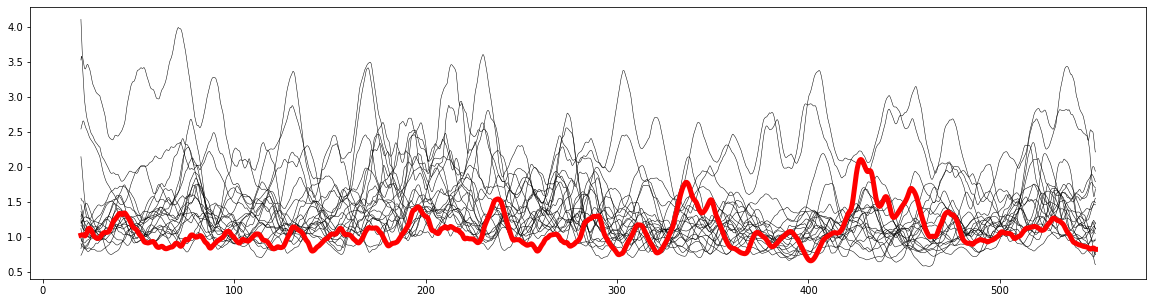

In [105]:
# WITH NORMALIZING:

#what do the reconstruction errors look like:
rec_errors_normalized = get_rec_errors_normalized(timeseries_dict,
        model_with_AV,
        normalizing_factors=normalizing_factors_with_AV,
        warmup_period=warmup_period)


rec_error_dict = deepcopy(rec_errors_normalized)

veh_ids = list(rec_error_dict.keys())

plt.figure(figsize = [20,5])
for veh_id in veh_ids:
    rec_error = rec_error_dict[veh_id][1]
    times = T_resampled[:,veh_id]
    if(veh_id != 12):
        plt.plot(times,rec_error,'k',linewidth=0.5)

veh_id = 12
rec_error = rec_error_dict[veh_id][1]
times = T_resampled[:,veh_id]
plt.plot(times,rec_error,'r',linewidth=5.0)

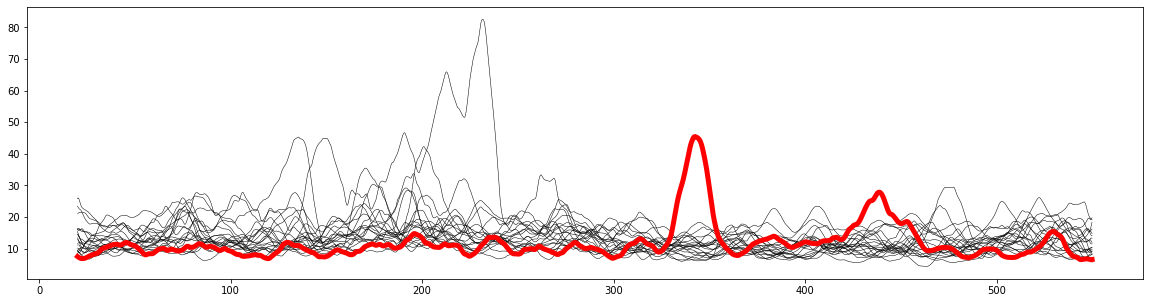

In [28]:
# WITHOUT NORMALZING:
rec_error_dict = deepcopy(rec_errors_normalized)

veh_ids = list(rec_error_dict.keys())

plt.figure(figsize = [20,5])
for veh_id in veh_ids:
    rec_error = rec_error_dict[veh_id]
    times = T_resampled[:,veh_id]
    if(veh_id != 12):
        plt.plot(times,rec_error,'k',linewidth=0.5)

veh_id = 12
rec_error = rec_error_dict[veh_id]
times = T_resampled[:,veh_id]
plt.plot(times,rec_error,'r',linewidth=5.0)

# Train with just human driving behavior:

In [95]:
train_begin = 600
train_end = 275*30 #until the end
 
V_train = V[train_begin:train_end,:]
S_train = S[train_begin:train_end,:]
VL_train = VL[train_begin:train_end,:]
T_train = T[train_begin:train_end,:]
X_train = X[train_begin:train_end,:]

_,_,_,_,_,trajectory_dict_no_AV = get_ARED_data_resampled_for_detection(T_train,V_train,S_train,VL_train,X_train)


warmup_period = 0.0

normalized_timeseries_list_no_AV,normalizing_factors_no_AV = make_timeseries_list_normalized(trajectory_dict_no_AV)


print('Training data prepared.')



Training data prepared.


In [96]:
model_no_AV = get_cnn_lstm_ae_model(n_features=4)

for i in range(4):
    print('Round '+str(i+1) + ' of training.')
    train_X = make_train_X(normalized_timeseries_list_no_AV)
    print('Training data prepared.')
    model_file_name = 'normalized_ARED_detector_NO_AV'
    model_no_AV = train_model(model_no_AV,train_X,model_file_name)

Round 1 of training.
Training data prepared.
Creating new model.
Best loss 6.5060110182989215
Beginning training.
Number epochs: 0 epoch step time: 1.0258922576904297
Epoch 0, total loss 921.690905, total predictions 210, avg loss 4.389004 2023-08-22 12:31:06.750699
Saving model. Best loss: 4.389004307701474
Number epochs: 1 epoch step time: 1.0203330516815186
Saving model. Best loss: 4.039538524264381
Number epochs: 2 epoch step time: 0.9431953430175781
Saving model. Best loss: 3.9254993802025204
Number epochs: 3 epoch step time: 0.8112990856170654
Saving model. Best loss: 3.8050577754066106
Number epochs: 4 epoch step time: 0.7882277965545654
Saving model. Best loss: 3.754390562148321
Number epochs: 5 epoch step time: 0.7945747375488281
Epoch 5, total loss 771.411808, total predictions 210, avg loss 3.673390 2023-08-22 12:31:11.109023
Saving model. Best loss: 3.6733895619710286
Number epochs: 6 epoch step time: 0.8276138305664062
Saving model. Best loss: 3.4723065648760114
Number epo

Number epochs: 86 epoch step time: 0.73508620262146
Saving model. Best loss: 1.831576717467535
Number epochs: 87 epoch step time: 0.7391469478607178
Number epochs: 88 epoch step time: 0.7414658069610596
Number epochs: 89 epoch step time: 0.7311317920684814
Number epochs: 90 epoch step time: 0.7374579906463623
Epoch 90, total loss 374.136884, total predictions 210, avg loss 1.781604 2023-08-22 12:32:14.936584
Saving model. Best loss: 1.7816042116710118
Number epochs: 91 epoch step time: 0.7467708587646484
Number epochs: 92 epoch step time: 0.7235808372497559
Number epochs: 93 epoch step time: 0.8959569931030273
Saving model. Best loss: 1.7568874779201689
Number epochs: 94 epoch step time: 0.8104109764099121
Number epochs: 95 epoch step time: 0.7580032348632812
Epoch 95, total loss 371.775773, total predictions 210, avg loss 1.770361 2023-08-22 12:32:18.872100
Number epochs: 96 epoch step time: 0.7363009452819824
Number epochs: 97 epoch step time: 0.731968879699707
Number epochs: 98 epoc

Number epochs: 31 epoch step time: 0.7298228740692139
Number epochs: 32 epoch step time: 0.7433547973632812
Number epochs: 33 epoch step time: 0.7293970584869385
Number epochs: 34 epoch step time: 0.7257819175720215
Number epochs: 35 epoch step time: 0.7277069091796875
Epoch 35, total loss 358.885021, total predictions 210, avg loss 1.708976 2023-08-22 12:33:26.338790
Number epochs: 36 epoch step time: 0.734982967376709
Number epochs: 37 epoch step time: 0.7306580543518066
Number epochs: 38 epoch step time: 0.759376049041748
Number epochs: 39 epoch step time: 0.7288250923156738
Number epochs: 40 epoch step time: 0.7344090938568115
Epoch 40, total loss 339.590557, total predictions 210, avg loss 1.617098 2023-08-22 12:33:30.027872
Number epochs: 41 epoch step time: 0.7518210411071777
Saving model. Best loss: 1.5646476881844658
Number epochs: 42 epoch step time: 0.7388138771057129
Number epochs: 43 epoch step time: 0.7462983131408691
Number epochs: 44 epoch step time: 0.7265920639038086


Number epochs: 136 epoch step time: 0.7284739017486572
Saving model. Best loss: 1.4208558763776507
Number epochs: 137 epoch step time: 0.7338109016418457
Number epochs: 138 epoch step time: 0.7481789588928223
Number epochs: 139 epoch step time: 0.7418148517608643
Number epochs: 140 epoch step time: 0.7355611324310303
Epoch 140, total loss 319.193635, total predictions 210, avg loss 1.519970 2023-08-22 12:34:43.295255
Number epochs: 141 epoch step time: 0.7419252395629883
Number epochs: 142 epoch step time: 0.7251520156860352
Number epochs: 143 epoch step time: 0.7299821376800537
Number epochs: 144 epoch step time: 0.7235720157623291
Saving model. Best loss: 1.4046686626615978
Number epochs: 145 epoch step time: 0.7381980419158936
Epoch 145, total loss 319.869261, total predictions 210, avg loss 1.523187 2023-08-22 12:34:46.954826
Number epochs: 146 epoch step time: 0.7312109470367432
Number epochs: 147 epoch step time: 0.7270119190216064
Number epochs: 148 epoch step time: 0.7259869575

Number epochs: 81 epoch step time: 0.739638090133667
Number epochs: 82 epoch step time: 0.7272489070892334
Number epochs: 83 epoch step time: 0.7351639270782471
Number epochs: 84 epoch step time: 0.7260720729827881
Saving model. Best loss: 1.199586838767642
Number epochs: 85 epoch step time: 0.7425680160522461
Epoch 85, total loss 265.473124, total predictions 210, avg loss 1.264158 2023-08-22 12:35:54.419072
Number epochs: 86 epoch step time: 0.7294440269470215
Number epochs: 87 epoch step time: 0.7301099300384521
Number epochs: 88 epoch step time: 0.7362289428710938
Number epochs: 89 epoch step time: 0.7395031452178955
Number epochs: 90 epoch step time: 0.7395370006561279
Epoch 90, total loss 267.686640, total predictions 210, avg loss 1.274698 2023-08-22 12:35:58.094650
Number epochs: 91 epoch step time: 0.7361190319061279
Number epochs: 92 epoch step time: 0.7316391468048096
Number epochs: 93 epoch step time: 0.7307751178741455
Number epochs: 94 epoch step time: 0.7359340190887451


Number epochs: 30 epoch step time: 0.7244269847869873
Epoch 30, total loss 264.928646, total predictions 210, avg loss 1.261565 2023-08-22 12:37:05.819646
Number epochs: 31 epoch step time: 0.7325906753540039
Number epochs: 32 epoch step time: 0.7297177314758301
Number epochs: 33 epoch step time: 0.7306420803070068
Number epochs: 34 epoch step time: 0.7295098304748535
Number epochs: 35 epoch step time: 0.7278730869293213
Epoch 35, total loss 285.930123, total predictions 210, avg loss 1.361572 2023-08-22 12:37:09.470671
Number epochs: 36 epoch step time: 0.7257461547851562
Number epochs: 37 epoch step time: 0.7308988571166992
Number epochs: 38 epoch step time: 0.7286181449890137
Number epochs: 39 epoch step time: 0.7339508533477783
Saving model. Best loss: 1.224571770713443
Number epochs: 40 epoch step time: 0.73944091796875
Epoch 40, total loss 276.470850, total predictions 210, avg loss 1.316528 2023-08-22 12:37:13.130020
Number epochs: 41 epoch step time: 0.7272958755493164
Number e

Number epochs: 135 epoch step time: 0.7306709289550781
Epoch 135, total loss 236.736604, total predictions 210, avg loss 1.127317 2023-08-22 12:38:22.637851
Number epochs: 136 epoch step time: 0.7323877811431885
Number epochs: 137 epoch step time: 0.7780699729919434
Number epochs: 138 epoch step time: 0.7298970222473145
Saving model. Best loss: 1.0785231987635295
Number epochs: 139 epoch step time: 0.7475981712341309
Number epochs: 140 epoch step time: 0.7349090576171875
Epoch 140, total loss 262.302070, total predictions 210, avg loss 1.249057 2023-08-22 12:38:26.361393
Number epochs: 141 epoch step time: 0.730076789855957
Number epochs: 142 epoch step time: 0.7280828952789307
Number epochs: 143 epoch step time: 0.7437098026275635
Number epochs: 144 epoch step time: 0.7435939311981201
Number epochs: 145 epoch step time: 0.7299220561981201
Epoch 145, total loss 231.149670, total predictions 210, avg loss 1.100713 2023-08-22 12:38:30.037568
Number epochs: 146 epoch step time: 0.77326273

Vehicles processed: 20/21, total compute time: 115.27420091629028

Total time to calculate loses: 121.8493058681488


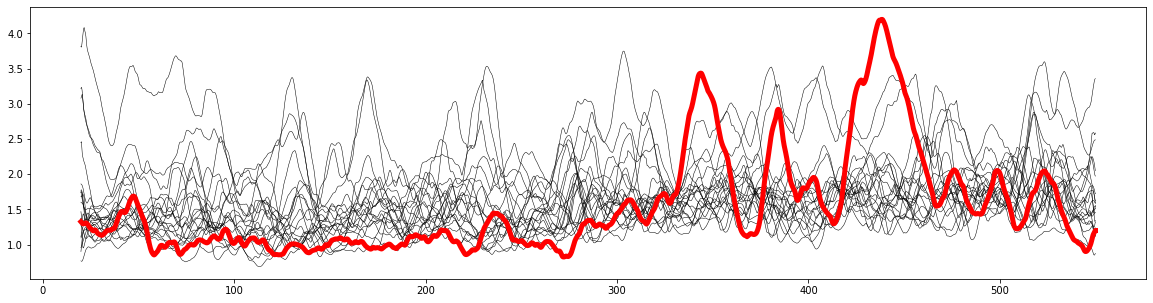

In [106]:
#what do the reconstruction errors look like:
rec_errors_normalized_no_AV = get_rec_errors_normalized(timeseries_dict,
        model_no_AV,
        normalizing_factors=normalizing_factors_no_AV,
        warmup_period=warmup_period)

veh_ids = list(rec_errors_normalized_no_AV.keys())

plt.figure(figsize = [20,5])
for veh_id in veh_ids:
    rec_error = rec_errors_normalized_no_AV[veh_id][1]
    times = T_resampled[:,veh_id]
    if(veh_id != 12):
        plt.plot(times,rec_error,'k',linewidth=0.5)

veh_id = 12
rec_error = rec_errors_normalized_no_AV[veh_id][1]
times = T_resampled[:,veh_id]
plt.plot(times,rec_error,'r',linewidth=5.0)

# How do the different models compare?

In [30]:
model_no_AV = get_cnn_lstm_ae_model(n_features=4)

model_path = 'models/cnn_lstm_ae_ARED_detector1.0percentGPS.pt'

model_no_AV.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [31]:
rec_error_dict_no_AV_in_training = get_rec_errors(timeseries_dict,model_no_AV)

Vehicles processed: 21



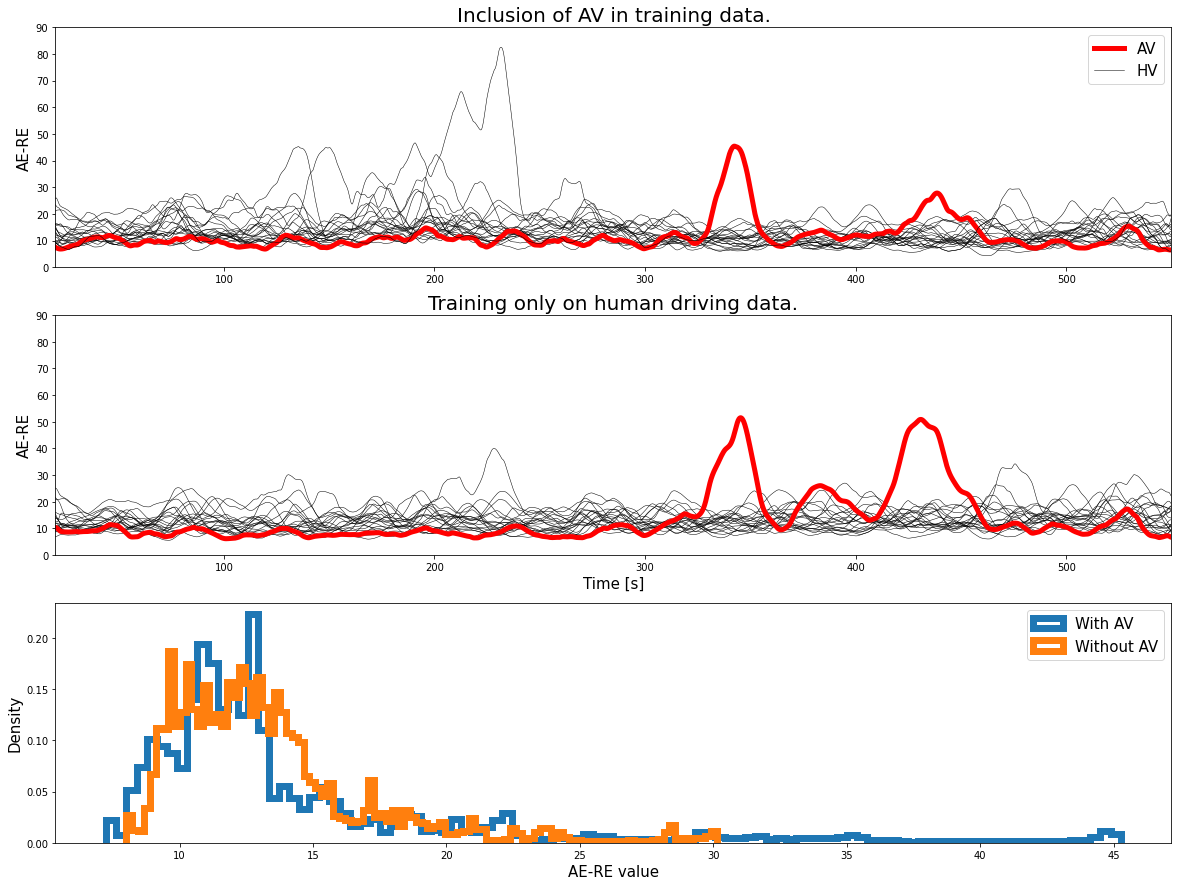

In [67]:
fig = plt.figure(figsize = [20,15])

plt.subplot(3,1,1)
for veh_id in veh_ids:
    rec_error= rec_error_dict[veh_id]
    times = T_resampled[:,veh_id]
    if(veh_id != 12):
        plt.plot(times,rec_error,'k',linewidth=0.5)

veh_id = 12
rec_error = rec_error_dict[veh_id]
times = T_resampled[:,veh_id]
plt.plot(times,rec_error,'r',linewidth=5.0,label='AV')

veh_id = 11
rec_error = rec_error_dict[veh_id]
times = T_resampled[:,veh_id]
plt.plot(times,rec_error,'k',linewidth=0.5,label='HV')
plt.ylabel('AE-RE',fontsize=15)
plt.ylim([0,90])
plt.xlim([20,550])
plt.title('Inclusion of AV in training data.',fontsize=20)
plt.legend(fontsize=15)


plt.subplot(3,1,2)

for veh_id in veh_ids:
    rec_error = rec_error_dict_no_AV_in_training[veh_id]
    times = T_resampled[:,veh_id]
    if(veh_id != 12):
        plt.plot(times,rec_error,'k',linewidth=0.5)

veh_id = 12
rec_error = rec_error_dict_no_AV_in_training[veh_id]
times = T_resampled[:,veh_id]
plt.plot(times,rec_error,'r',linewidth=5.0)

plt.ylabel('AE-RE',fontsize=15)
plt.xlabel('Time [s]',fontsize=15)
plt.ylim([0,90])
plt.xlim([20,550])
plt.title('Training only on human driving data.',fontsize=20)


plt.subplot(3,1,3)

n,b,_ = plt.hist(rec_error_with_AV_stacked,100,density=True,histtype='step',linewidth=7)
n,b,_ = plt.hist(rec_error_no_AV_stacked,100,density=True,histtype='step',linewidth=7)
plt.legend(['With AV','Without AV'],fontsize=15)
plt.ylabel('Density',fontsize=15)
plt.xlabel('AE-RE value',fontsize=15)


plt.savefig("Training_With_vs_Without_AV_ARED.png",bbox_inches='tight')

In [44]:
rec_error_with_AV_stacked = rec_error_dict[0]
for i in range(1,21):
    np.concatenate((rec_error_with_AV_stacked,rec_error_dict[i]))
                   
rec_error_no_AV_stacked = rec_error_dict_no_AV_in_training[0]
for i in range(1,21):
    np.concatenate((rec_error_with_AV_stacked,rec_error_dict_no_AV_in_training[i]))
   

Text(0.5, 0, 'AE-RE')

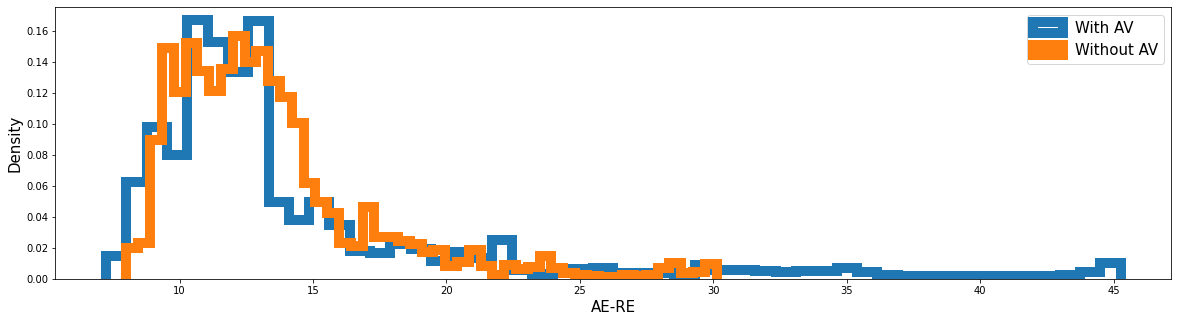

In [62]:
plt.figure(figsize=[20,5])

n,b,_ = plt.hist(rec_error_with_AV_stacked,50,density=True,histtype='step',linewidth=10)
n,b,_ = plt.hist(rec_error_no_AV_stacked,50,density=True,histtype='step',linewidth=10)
plt.legend(['With AV','Without AV'],fontsize=15)
plt.ylabel('Density',fontsize=15)
plt.xlabel('AE-RE',fontsize=15)

# What about if a unique detector trained just on AV?

In [164]:
reload(utils)

print('loading data.')

train_begin = 300*30
train_end = 550*30 #until the end


num_time_samples = train_end - train_begin

AV_id = 12


V_train = V[train_begin:train_end,AV_id].reshape((num_time_samples,1))
S_train = S[train_begin:train_end,AV_id].reshape((num_time_samples,1))
VL_train = VL[train_begin:train_end,AV_id].reshape((num_time_samples,1))
T_train = T[train_begin:train_end,AV_id].reshape((num_time_samples,1))
X_train = X[train_begin:train_end,AV_id].reshape((num_time_samples,1))

print('Selected training data.')

V_resampled,S_resampled,T_resampled,X_resampled,VL_resampled,timeseries_dict_AV_only = get_ARED_data_resampled_for_detection(T_train,V_train,S_train,VL_train,X_train)

model_AV_only = get_cnn_lstm_ae_model(n_features=4)

model_name = 'ARED_AV_only'

loading data.
Selected training data.
range(0, 1)


In [140]:
model_AV_only = train_detector(timeseries_dict=timeseries_dict,
                               model_name='ARED_AV_only',
                               n_epoch=100,
                               num_samples_per_veh=100)

for i in range(3):
    model_AV_only = train_detector(timeseries_dict=timeseries_dict,
                                   model_name='ARED_AV_only',
                                   n_epoch=100,
                                   num_samples_per_veh=100)

Model: ARED_AV_only
Beginning training...
Creating new model.
Best loss 136.29169555664063
Beginning training.
Number epochs: 0 epoch step time: 0.4853081703186035
Epoch 0, total loss 13227.610565, total predictions 100, avg loss 132.276106 2023-09-05 10:07:24.283304
Saving model. Best loss: 132.27610565185546
Number epochs: 1 epoch step time: 0.5506041049957275
Saving model. Best loss: 123.40686065673827
Number epochs: 2 epoch step time: 0.45778918266296387
Saving model. Best loss: 111.08685302734375
Number epochs: 3 epoch step time: 0.5086369514465332
Saving model. Best loss: 99.31909515380859
Number epochs: 4 epoch step time: 0.45232391357421875
Saving model. Best loss: 88.42179412841797
Number epochs: 5 epoch step time: 0.44395899772644043
Epoch 5, total loss 7949.844604, total predictions 100, avg loss 79.498446 2023-09-05 10:07:26.697306
Saving model. Best loss: 79.49844604492188
Number epochs: 6 epoch step time: 0.43928027153015137
Saving model. Best loss: 72.93126815795898
Numb

Number epochs: 71 epoch step time: 0.3741457462310791
Number epochs: 72 epoch step time: 0.3703930377960205
Number epochs: 73 epoch step time: 0.37236905097961426
Saving model. Best loss: 25.488905029296873
Number epochs: 74 epoch step time: 0.3773529529571533
Saving model. Best loss: 25.042629852294922
Number epochs: 75 epoch step time: 0.37313199043273926
Epoch 75, total loss 2467.051956, total predictions 100, avg loss 24.670520 2023-09-05 10:07:54.707271
Saving model. Best loss: 24.670519561767577
Number epochs: 76 epoch step time: 0.379626989364624
Saving model. Best loss: 24.069113235473633
Number epochs: 77 epoch step time: 0.37238097190856934
Saving model. Best loss: 23.79969337463379
Number epochs: 78 epoch step time: 0.3728768825531006
Number epochs: 79 epoch step time: 0.38046693801879883
Saving model. Best loss: 23.570808563232422
Number epochs: 80 epoch step time: 0.3814840316772461
Epoch 80, total loss 2348.442299, total predictions 100, avg loss 23.484423 2023-09-05 10:0

Number epochs: 54 epoch step time: 0.3856842517852783
Number epochs: 55 epoch step time: 0.37443089485168457
Epoch 55, total loss 2013.144867, total predictions 100, avg loss 20.131449 2023-09-05 10:08:24.914140
Number epochs: 56 epoch step time: 0.3685591220855713
Number epochs: 57 epoch step time: 0.3699021339416504
Number epochs: 58 epoch step time: 0.370772123336792
Number epochs: 59 epoch step time: 0.37608885765075684
Number epochs: 60 epoch step time: 0.3698129653930664
Epoch 60, total loss 2171.340752, total predictions 100, avg loss 21.713408 2023-09-05 10:08:26.770228
Number epochs: 61 epoch step time: 0.367717981338501
Saving model. Best loss: 19.68621337890625
Number epochs: 62 epoch step time: 0.37334704399108887
Number epochs: 63 epoch step time: 0.37169408798217773
Number epochs: 64 epoch step time: 0.36737918853759766
Number epochs: 65 epoch step time: 0.36936092376708984
Epoch 65, total loss 1941.243027, total predictions 100, avg loss 19.412430 2023-09-05 10:08:28.620

Number epochs: 39 epoch step time: 0.38282179832458496
Saving model. Best loss: 14.336308708190918
Number epochs: 40 epoch step time: 0.3884108066558838
Epoch 40, total loss 1506.690041, total predictions 100, avg loss 15.066900 2023-09-05 10:09:00.405443
Number epochs: 41 epoch step time: 0.3715090751647949
Number epochs: 42 epoch step time: 0.3821139335632324
Number epochs: 43 epoch step time: 0.389711856842041
Number epochs: 44 epoch step time: 0.3774452209472656
Number epochs: 45 epoch step time: 0.3734090328216553
Epoch 45, total loss 1443.200851, total predictions 100, avg loss 14.432009 2023-09-05 10:09:02.300369
Number epochs: 46 epoch step time: 0.3824000358581543
Number epochs: 47 epoch step time: 0.3899571895599365
Number epochs: 48 epoch step time: 0.37711095809936523
Number epochs: 49 epoch step time: 0.37999582290649414
Number epochs: 50 epoch step time: 0.37269091606140137
Epoch 50, total loss 1545.532562, total predictions 100, avg loss 15.455326 2023-09-05 10:09:04.203

Number epochs: 31 epoch step time: 0.3929729461669922
Saving model. Best loss: 11.946515235900879
Number epochs: 32 epoch step time: 0.3877451419830322
Saving model. Best loss: 11.72752140045166
Number epochs: 33 epoch step time: 0.38617610931396484
Number epochs: 34 epoch step time: 0.3897528648376465
Saving model. Best loss: 11.71163719177246
Number epochs: 35 epoch step time: 0.3859372138977051
Epoch 35, total loss 1154.751453, total predictions 100, avg loss 11.547515 2023-09-05 10:09:37.088346
Saving model. Best loss: 11.547514533996582
Number epochs: 36 epoch step time: 0.3882901668548584
Number epochs: 37 epoch step time: 0.38486194610595703
Number epochs: 38 epoch step time: 0.3848378658294678
Number epochs: 39 epoch step time: 0.3847939968109131
Number epochs: 40 epoch step time: 0.38863110542297363
Epoch 40, total loss 1208.657894, total predictions 100, avg loss 12.086579 2023-09-05 10:09:39.020526
Number epochs: 41 epoch step time: 0.394484281539917
Number epochs: 42 epoch 

In [152]:
V_HVs = np.concatenate((V[train_begin:train_end,0:AV_id],
                        V[train_begin:train_end,AV_id+1:]),axis=1)

S_HVs = np.concatenate((V[train_begin:train_end,0:AV_id],
                        V[train_begin:train_end,AV_id+1:]),axis=1)

VL_HVs = np.concatenate((VL[train_begin:train_end,0:AV_id],
                        VL[train_begin:train_end,AV_id+1:]),axis=1)

T_HVs = np.concatenate((T[train_begin:train_end,0:AV_id],
                        T[train_begin:train_end,AV_id+1:]),axis=1)

X_HVs = np.concatenate((X[train_begin:train_end,0:AV_id],
                        X[train_begin:train_end,AV_id+1:]),axis=1)

# BUG: NEED TO RESAMPLE

_,_,_,_,_,timeseries_dict_testing_humans = get_ARED_data_resampled_for_detection(T_HVs,V_HVs,S_HVs,VL_HVs,X_HVs)


model_HVs = get_cnn_lstm_ae_model(n_features=4)

model_path = 'models/cnn_lstm_ae_ARED_detector_NO_AV.pt'

model_HVs.load_state_dict(torch.load(model_path))

rec_error_HVs_only = get_rec_errors(
    timeseries_dict_testing_humans,
    model_HVs)

range(0, 20)
Vehicles processed: 20



In [165]:
rec_error_HV_detect_on_AV = get_rec_errors(
    timeseries_dict_AV_only,
    model_HVs)

Vehicles processed: 1



Text(0.5, 1.0, 'Effect of AV aware detection')

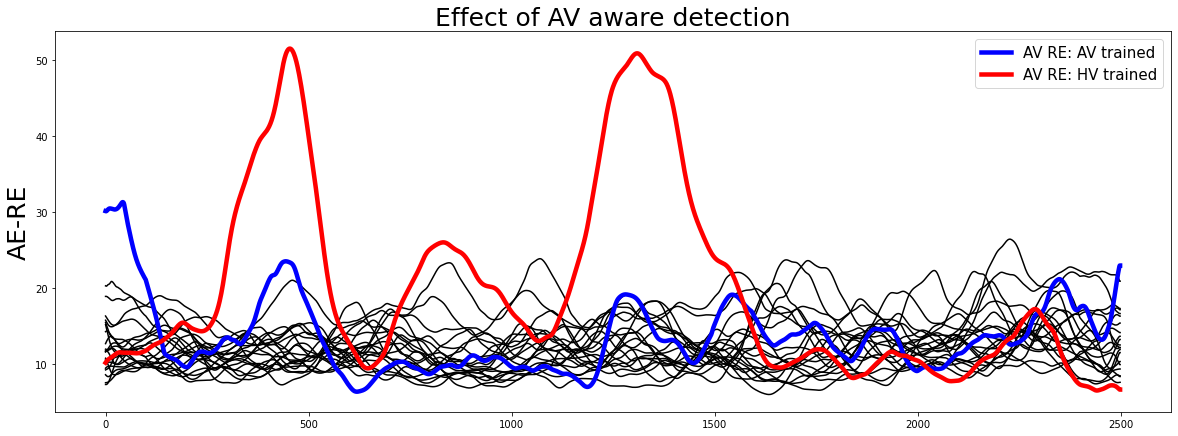

In [174]:
plt.figure(figsize=[20,7])

for veh_id in rec_error_HVs_only:
    rec_error = rec_error_HVs_only[veh_id]
    plt.plot(rec_error,'k',linewidth=1.5)

rec_error_AV_only = rec_error_dict_sim_AV_only[0]
plt.plot(rec_error_AV_only,'b',linewidth=4.5,label='AV RE: AV trained')
    

rec_error_HV_on_AV = rec_error_HV_detect_on_AV[0]
plt.plot(rec_error_HV_on_AV,'r',linewidth=4.5,label='AV RE: HV trained')  
    
plt.ylabel('AE-RE',fontsize=25)
# plt.ylim([0,90])
# plt.xlim([20,550])
# plt.title('Detection, no attack, no AV in training',fontsize=20)
plt.legend(fontsize=15)
plt.title('Effect of AV aware detection',fontsize=25)

# Look at how the two different detectors work with a simulation:

In [56]:
from detector_dev.Process_RingRoad_Simulation.utils import run_ring_sim_variable_cfm,Bando_OVM_FTL

from Adversaries.controllers.car_following_adversarial import ACC_Switched_Controller_Attacked


ring_length = 250

driver_controller_list = []

num_HV_drivers = 21

# Human drivers:
a=0.666
b=21.6
s0=2.21
s1=2.82
Vm=8.94

label = 'bando_ftl_ovm_a'+str(np.round(a,2))+'_b'+str(np.round(b,2))+'_s0'+str(np.round(s0,2))+'_s1'+str(np.round(s1,2))+'_Vm'+str(np.round(Vm,2))

cfm_controller = (Bando_OVM_FTL,{'a':a,'b':b,'s0':s0,'s1':s1,'Vm':Vm,'noise':0.05})

driver_controller_list.append([label,cfm_controller,num_HV_drivers])


# compromised ACC:
k_1  = 1.5
k_2 = 0.2
h = 1.8
V_m = 15.0
d_min = 10.0

warmup_steps = 200
SS_Threshold_min = 60
display_attack_info = True

want_multiple_attacks = True

# start with no attack:
Total_Attack_Duration = 0.0
attack_decel_rate = 0.0


adversary = (ACC_Switched_Controller_Attacked, {'k_1':k_1,'k_2':k_2,'h':h,'V_m':V_m,'d_min':d_min,
                                                'want_multiple_attacks':want_multiple_attacks,
                                                'Total_Attack_Duration':Total_Attack_Duration,
                                                'attack_decel_rate':attack_decel_rate,
                                                'warmup_steps':warmup_steps,
                                                'SS_Threshold_min':SS_Threshold_min,
                                                'display_attack_info':display_attack_info})


ACC_label = '_k1_'+str(np.round(k_1,2))+'_k2_'+str(np.round(k_2,2))+'_h_'+str(np.round(h,2))+'_Vm_'+str(np.round(V_m,2))+'_dm_'+str(np.round(d_min,2))

label_adv = 'RDA_adv_TDA_'+str(np.round(Total_Attack_Duration,2))+'_ADR_'+str(np.round(attack_decel_rate,2))

label_adv = label_adv + ACC_label

driver_controller_list.append([label_adv,adversary,1])


sim_res_list = run_ring_sim_variable_cfm(ring_length,driver_controller_list)

sim_res_path = os.path.join(os.getcwd(),sim_res_list[1])


Number of classes of driver: 2
Running ring simulation, ring length: 250
Spawning compromised ACC, attack frequency: 80.52644507669153
Will engage in multiple attacks.
Beginning attack: RDA_adv_TDA_0.0_ADR_0.0_k1_1.5_k2_0.2_h_1.8_Vm_15.0_dm_10.0_0 Time: 80.9
Attack finished:RDA_adv_TDA_0.0_ADR_0.0_k1_1.5_k2_0.2_h_1.8_Vm_15.0_dm_10.0_0, 0.0, 0.0, 81.0
Beginning attack: RDA_adv_TDA_0.0_ADR_0.0_k1_1.5_k2_0.2_h_1.8_Vm_15.0_dm_10.0_0 Time: 161.60000000000002
Attack finished:RDA_adv_TDA_0.0_ADR_0.0_k1_1.5_k2_0.2_h_1.8_Vm_15.0_dm_10.0_0, 0.0, 0.0, 161.70000000000002
Beginning attack: RDA_adv_TDA_0.0_ADR_0.0_k1_1.5_k2_0.2_h_1.8_Vm_15.0_dm_10.0_0 Time: 242.4
Attack finished:RDA_adv_TDA_0.0_ADR_0.0_k1_1.5_k2_0.2_h_1.8_Vm_15.0_dm_10.0_0, 0.0, 0.0, 242.5
Beginning attack: RDA_adv_TDA_0.0_ADR_0.0_k1_1.5_k2_0.2_h_1.8_Vm_15.0_dm_10.0_0 Time: 323.20000000000005
Attack finished:RDA_adv_TDA_0.0_ADR_0.0_k1_1.5_k2_0.2_h_1.8_Vm_15.0_dm_10.0_0, 0.0, 0.0, 323.3
Beginning attack: RDA_adv_TDA_0.0_ADR_0.0_k1_1.

/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/opt/anaconda3/envs/anti_flow/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Round 0, Return: 1426.4301266187108
data/ring_variable_cfm_20230821-1214011692638041.8309639-0_emission.csv data
Average, std velocities: 3.548889075943677, 0.0
Average, std outflows: 0.0, 0.0
Average, std avg_trip_energy: nan, nan
Average, std avg_trip_time: nan, nan
Average, std total_completed_trips: 0.0, 0.0
Average, std returns: 1426.4301266187108, 0.0
Total time: 25.42931890487671
steps/second: 231.32480077296518


NameError: name 'sim_res_list_with_attack' is not defined

In [109]:
emission_file_path = sim_res_path

timeseries_dict_sim_no_attack = get_trajectory_timeseries(
    csv_path=emission_file_path,
    warmup_period=warmup_period)

Data loaded, total time: 1.0247392654418945


# with no AV in training:

In [117]:
model_no_AV = get_cnn_lstm_ae_model(n_features=4)

model_path = 'models/cnn_lstm_ae_ARED_detector_NO_AV.pt'

model_no_AV.load_state_dict(torch.load(model_path))


rec_error_dict_sim_no_attack_no_AV_in_training = get_rec_errors(
    timeseries_dict_sim_no_attack,
    model_no_AV)

Vehicles processed: 22



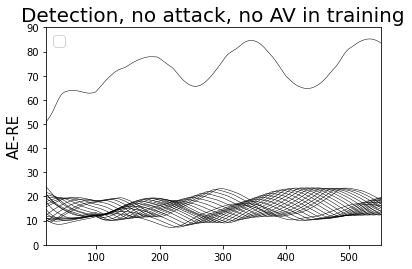

In [118]:
veh_ids = list(rec_error_dict_sim_no_attack_no_AV_in_training.keys())

for veh_id in veh_ids:
    rec_error = rec_error_dict_sim_no_attack_no_AV_in_training[veh_id]
    plt.plot(rec_error,'k',linewidth=0.5)

plt.ylabel('AE-RE',fontsize=15)
plt.ylim([0,90])
plt.xlim([20,550])
plt.title('Detection, no attack, no AV in training',fontsize=20)
plt.legend(fontsize=15)



# with AV in training:

In [120]:
model_with_AV = get_cnn_lstm_ae_model(n_features=4)

model_path = 'models/cnn_lstm_ae_ARED_detector_ALL_DATA.pt'

model_with_AV.load_state_dict(torch.load(model_path))

rec_error_dict_sim_no_attack_with_AV_in_training = get_rec_errors(timeseries_dict_sim_no_attack,model_with_AV)

Vehicles processed: 22



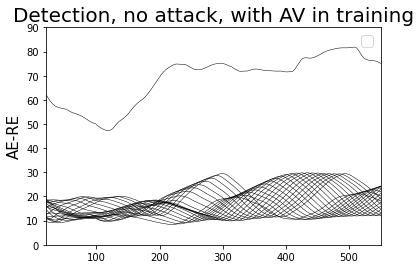

In [123]:
veh_ids = list(rec_error_dict_sim_no_attack_with_AV_in_training.keys())


# plt.figure(figsize=[20,5])

for veh_id in veh_ids:
    rec_error = rec_error_dict_sim_no_attack_with_AV_in_training[veh_id]
    plt.plot(rec_error,'k',linewidth=0.5)


plt.ylabel('AE-RE',fontsize=15)
plt.ylim([0,90])
plt.xlim([20,550])
plt.title('Detection, no attack, with AV in training',fontsize=20)
plt.legend(fontsize=15)



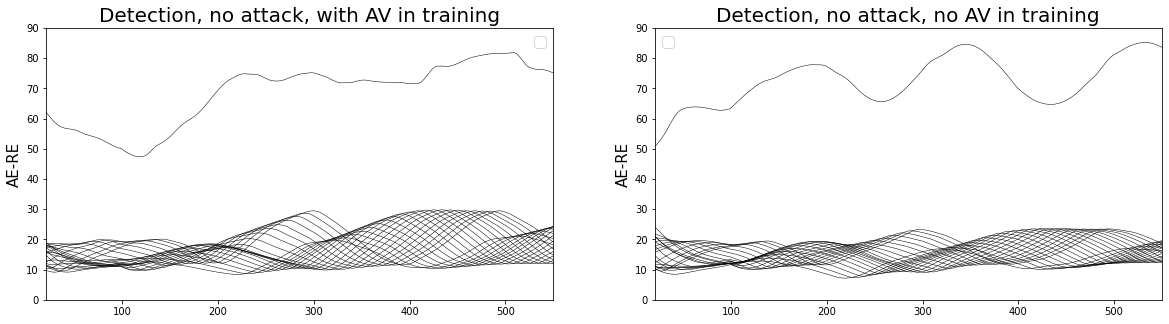

In [126]:
plt.figure(figsize=[20,5])


plt.subplot(1,2,1)

veh_ids = list(rec_error_dict_sim_no_attack_with_AV_in_training.keys())

for veh_id in veh_ids:
    rec_error = rec_error_dict_sim_no_attack_with_AV_in_training[veh_id]
    plt.plot(rec_error,'k',linewidth=0.5)


plt.ylabel('AE-RE',fontsize=15)
plt.ylim([0,90])
plt.xlim([20,550])
plt.title('Detection, no attack, with AV in training',fontsize=20)
# plt.legend(fontsize=15)


plt.subplot(1,2,2)

veh_ids = list(rec_error_dict_sim_no_attack_no_AV_in_training.keys())

for veh_id in veh_ids:
    rec_error = rec_error_dict_sim_no_attack_no_AV_in_training[veh_id]
    plt.plot(rec_error,'k',linewidth=0.5)


plt.ylabel('AE-RE',fontsize=15)
plt.ylim([0,90])
plt.xlim([20,550])
plt.title('Detection, no attack, no AV in training',fontsize=20)
# plt.legend(fontsize=15)